In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('netflix1.csv')
df = pd.read_csv('netflix1.csv', parse_dates=["date_added"])
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   str           
 1   type          8790 non-null   str           
 2   title         8790 non-null   str           
 3   director      8790 non-null   str           
 4   country       8790 non-null   str           
 5   date_added    8790 non-null   datetime64[us]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   str           
 8   duration      8790 non-null   str           
 9   listed_in     8790 non-null   str           
dtypes: datetime64[us](1), int64(1), str(8)
memory usage: 686.8 KB


In [28]:
df.shape

(8790, 10)

In [29]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
# for col in df.columns:
#     print("\nCOLUMN:", col)
#     print("Unique:", df[col].nunique())
#     print(df[col].value_counts(dropna=False).head(15))
for col in df.select_dtypes(include="object").columns:
    print("-----", col)
    print(df[col].value_counts().head(20))




----- show_id
show_id
s1       1
s3       1
s6       1
s14      1
s8       1
s9       1
s10      1
s939     1
s13      1
s940     1
s941     1
s942     1
s852     1
s471     1
s730     1
s731     1
s913     1
s4       1
s15      1
s3232    1
Name: count, dtype: int64
----- type
type
Movie      6126
TV Show    2664
Name: count, dtype: int64
----- title
title
9-Feb                               2
15-Aug                              2
22-Jul                              2
Dick Johnson Is Dead                1
Ganglands                           1
Midnight Mass                       1
Confessions of an Invisible Girl    1
Sankofa                             1
The Great British Baking Show       1
The Starling                        1
Motu Patlu in the Game of Zones     1
Je Suis Karl                        1
Motu Patlu in Wonderland            1
Motu Patlu: Deep Sea Adventure      1
Motu Patlu: Mission Moon            1
99 Songs (Tamil)                    1
Bridgerton - The Afterparty     

C:\Users\hieum\AppData\Local\Temp\ipykernel_40904\2853998411.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [32]:
for col in df.columns:
    print("-----", col)
    print(df[col].value_counts(dropna=False).head(10))

----- show_id
show_id
s1      1
s3      1
s6      1
s14     1
s8      1
s9      1
s10     1
s939    1
s13     1
s940    1
Name: count, dtype: int64
----- type
type
Movie      6126
TV Show    2664
Name: count, dtype: int64
----- title
title
9-Feb                               2
15-Aug                              2
22-Jul                              2
Dick Johnson Is Dead                1
Ganglands                           1
Midnight Mass                       1
Confessions of an Invisible Girl    1
Sankofa                             1
The Great British Baking Show       1
The Starling                        1
Name: count, dtype: int64
----- director
director
Not Given                 2588
Rajiv Chilaka               20
Raúl Campos, Jan Suter      18
Alastair Fothergill         18
Suhas Kadav                 16
Marcus Raboy                16
Jay Karas                   14
Cathy Garcia-Molina         13
Youssef Chahine             12
Martin Scorsese             12
Name: count, dtype: 

In [33]:
bad_values = [
    "not given", "unknown", "n/a", "na", "none",
    "null", "missing", "-", "--", "?"
]

for col in df.select_dtypes(include="object").columns:
    temp = df[col].astype(str).str.strip().str.lower()
    count = temp.isin(bad_values).sum()
    
    if count > 0:
        print(col, count)


title 1
director 2588
country 287


C:\Users\hieum\AppData\Local\Temp\ipykernel_40904\1102967200.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [ ]:
bad_values = [
    "not given", "unknown", "n/a", "na", "none",
    "null", "missing", "-", "--", "?"
]

text_cols = df.select_dtypes(include=["object", "string"]).columns

mask = df[text_cols].apply(
    lambda col: col.astype(str).str.strip().str.lower().isin(bad_values)
)

df[mask.any(axis=1)]


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
12,s852,Movie,99 Songs (Tamil),Not Given,Pakistan,2021-05-21,2021,TV-14,131 min,"Dramas, International Movies, Music & Musicals"
17,s4,TV Show,Jailbirds New Orleans,Not Given,Pakistan,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV"
18,s15,TV Show,Crime Stories: India Detectives,Not Given,Pakistan,2021-09-22,2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries"
23,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha",Not Given,2021-09-24,2021,PG,91 min,Children & Family Movies
24,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,Not Given,2021-09-23,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV


In [35]:
df.describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466


In [37]:
bad_values = [
    "not given", "unknown", "n/a", "na", "none",
    "null", "missing", "-", "--", "?"
]

text_cols = df.select_dtypes(include=["object", "string"]).columns

bad_counts = {}

for col in text_cols:
    temp = df[col].astype(str).str.strip().str.lower()
    bad_counts[col] = temp.isin(bad_values).sum()

bad_counts = pd.Series(bad_counts)
bad_counts = bad_counts[bad_counts > 0]

bad_counts


title          1
director    2588
country      287
dtype: int64

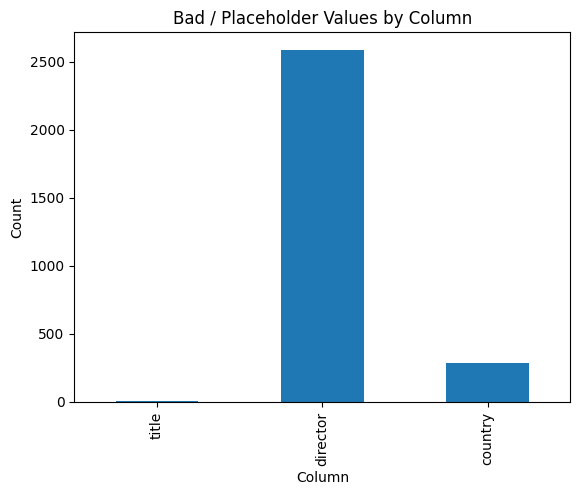

In [38]:
bad_counts.plot(kind="bar")

plt.title("Bad / Placeholder Values by Column")
plt.xlabel("Column")
plt.ylabel("Count")
plt.show()
